# LightGBM model

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../data/final_merged_dataset.parquet")
df = df.sort_values("day_datetime").reset_index(drop=True)

In [3]:
print(df.dtypes.value_counts())
print(df.shape)

float64           448
int64               7
str                 4
bool                4
datetime64[us]      1
object              1
Name: count, dtype: int64
(853536, 465)


In [4]:
print("str cols:", df.select_dtypes(include='object').columns.tolist())
print("bool cols:", df.select_dtypes(include='bool').columns.tolist())
print("datetime cols:", df.select_dtypes(include='datetime64').columns.tolist())

str cols: ['city_name', 'day_datetime', 'day_sunrise', 'day_sunset', 'region_key']
bool cols: ['hour_conditions_simple_Clear', 'hour_conditions_simple_Cloudy', 'hour_conditions_simple_Rain', 'hour_conditions_simple_Snow']
datetime cols: ['datetime_hour']


C:\Users\Uw11\AppData\Local\Temp\ipykernel_25456\1106464062.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("str cols:", df.select_dtypes(include='object').columns.tolist())


In [5]:
y = df['alarm_active']
X = df.drop(columns=['datetime_hour', 'alarm_active', 'alarm_minutes_in_hour', 'region_key', 'day_datetime', 'day_sunrise', 'day_sunset'], errors="ignore")

In [6]:
X = X.select_dtypes(include=["number", "bool"]).copy()
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype("int8")

In [7]:
split_index = int(len(X) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target balance train: {y_train.mean():.2%}")
print(f"Target balance test: {y_test.mean():.2%}")

Train: (682828, 457), Test: (170708, 457)
Target balance train: 19.02%
Target balance test: 30.83%


In [9]:
tscv = TimeSeriesSplit(n_splits=3)

In [10]:
param_grid = [
    {"n_estimators": 200, "learning_rate": 0.05, "num_leaves": 31},
    {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 63},
    {"n_estimators": 300, "learning_rate": 0.01, "num_leaves": 63},
]

best_score = -np.inf
best_params = None

for params in param_grid:
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = lgb.LGBMClassifier(
            **params,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
        model.fit(X_tr, y_tr)
        y_val_proba = model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_val_proba)
        scores.append(score)

    mean_score = np.mean(scores)
    print(f"{params} -> ROC-AUC: {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

print(f"\nBest params: {best_params}")
print(f"Best ROC-AUC: {best_score:.4f}")

{'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 31} -> ROC-AUC: 0.8896
{'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 63} -> ROC-AUC: 0.8887
{'n_estimators': 300, 'learning_rate': 0.01, 'num_leaves': 63} -> ROC-AUC: 0.8872

Best params: {'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 31}
Best ROC-AUC: 0.8896


In [11]:
lgbm_model = lgb.LGBMClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [12]:
y_pred = lgbm_model.predict(X_test)
y_proba = lgbm_model.predict_proba(X_test)[:, 1]

In [13]:
print("\n--- Default threshold (0.5) ---")
print(classification_report(y_test, y_pred, target_names=["No alarm", "Alarm"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

threshold = 0.4
y_pred_custom = (y_proba >= threshold).astype(int)
print(f"\n--- Custom threshold ({threshold}) ---")
print(classification_report(y_test, y_pred_custom, target_names=["No alarm", "Alarm"]))


--- Default threshold (0.5) ---
              precision    recall  f1-score   support

    No alarm       0.96      0.81      0.88    118087
       Alarm       0.68      0.92      0.78     52621

    accuracy                           0.84    170708
   macro avg       0.82      0.86      0.83    170708
weighted avg       0.87      0.84      0.85    170708

ROC-AUC: 0.94036400917726
PR-AUC: 0.8749522522684293

--- Custom threshold (0.4) ---
              precision    recall  f1-score   support

    No alarm       0.97      0.74      0.84    118087
       Alarm       0.61      0.95      0.74     52621

    accuracy                           0.80    170708
   macro avg       0.79      0.84      0.79    170708
weighted avg       0.86      0.80      0.81    170708



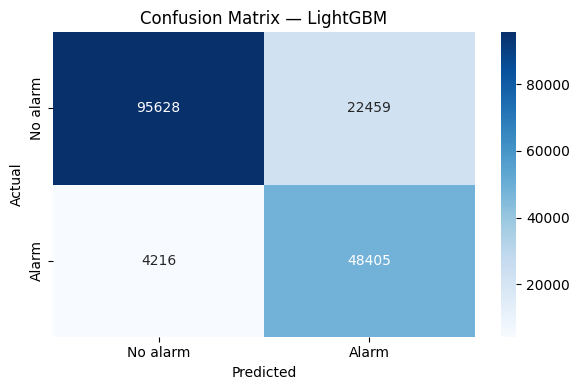

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No alarm", "Alarm"],
            yticklabels=["No alarm", "Alarm"])
plt.title("Confusion Matrix — LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [15]:
importances = pd.Series(lgbm_model.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

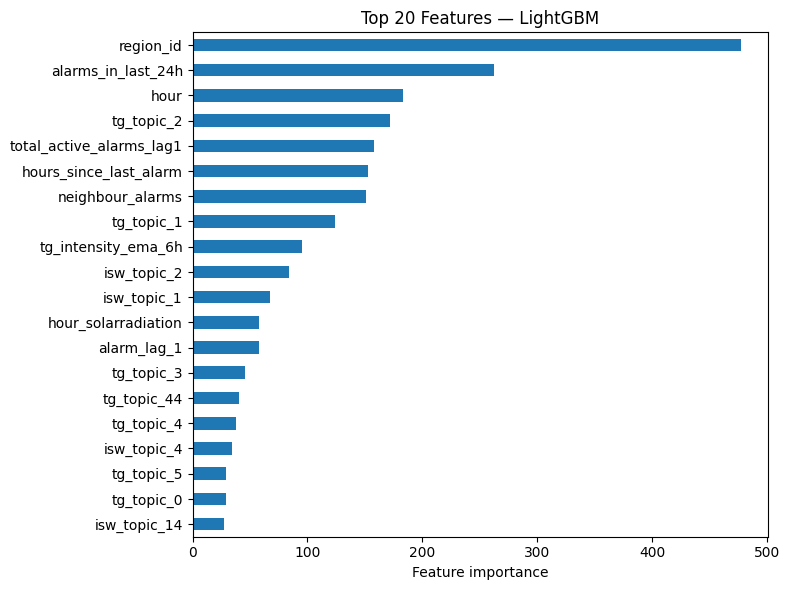

In [16]:
top20.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 20 Features — LightGBM")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

In [18]:
#with open("lgbm_model.pkl", "wb") as f:
#    pickle.dump(lgbm_model, f)
#print("Model saved: lgbm_model.pkl")